In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

import joblib
import os

In [4]:
df = pd.read_csv(
    "../data/processed/gps_clustered.csv"
)

print("Dataset shape:", df.shape)

Dataset shape: (24730077, 21)


In [5]:
df.head()

,user_id,latitude,longitude,altitude,date,time,timestamp,hour,day,weekday,...,is_weekend,previous_latitude,previous_longitude,previous_timestamp,distance_km,time_difference_seconds,speed_kmh,location,time_spent_minutes,cluster
0,0,39.984702,116.318417,492.0,2008-10-23,02:53:04,2008-10-23 02:53:04,2,23,Thursday,...,False,NaN,NaN,NaN,0.000000,0.0,0.000000,39.9847_116.3184,0.000000,9
1,0,39.984683,116.318450,492.0,2008-10-23,02:53:10,2008-10-23 02:53:10,2,23,Thursday,...,False,39.984702,116.318417,2008-10-23 02:53:04,0.002812,6.0,1.687092,39.9847_116.3184,0.100000,9
2,0,39.984686,116.318417,492.0,2008-10-23,02:53:15,2008-10-23 02:53:15,2,23,Thursday,...,False,39.984683,116.318450,2008-10-23 02:53:10,0.002812,5.0,2.024341,39.9847_116.3184,0.083333,9
3,0,39.984688,116.318385,492.0,2008-10-23,02:53:20,2008-10-23 02:53:20,2,23,Thursday,...,False,39.984686,116.318417,2008-10-23 02:53:15,0.002726,5.0,1.962995,39.9847_116.3184,0.083333,9
4,0,39.984655,116.318263,492.0,2008-10-23,02:53:25,2008-10-23 02:53:25,2,23,Thursday,...,False,39.984688,116.318385,2008-10-23 02:53:20,0.010395,5.0,7.484055,39.9847_116.3183,0.083333,9


In [6]:
features = [
    "latitude",
    "longitude",
    "distance_km",
    "speed_kmh",
    "hour"
]

X = df[features].copy()

print(X.shape)

(24730077, 5)


In [7]:
X = X.replace(
    [np.inf, -np.inf],
    np.nan
)

X = X.dropna()

print("Usable records:", len(X))

Usable records: 24730077


In [8]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Scaling completed!")

Scaling completed!


In [10]:
isolation_model = IsolationForest(
    n_estimators=50,
    contamination=0.01,
    random_state=42,
    n_jobs=2
)

isolation_model.fit(X_scaled)

,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",50
,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.01
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary <n_jobs>` for more details.",2
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary <warm_start>`... versionadded:: 0.21",False
Name,Type,Value
estimator_ estimator_: :class:`~sklearn.tree.ExtraTreeRegressor` instanceThe child estimator template used to create the collection offitted sub-estimators... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,ExtraTreeRegressor,ExtraTreeRegr...ndom_state=42)


In [11]:
predictions = isolation_model.predict(
    X_scaled
)

print("Prediction completed!")

Prediction completed!


In [12]:
df["anomaly"] = 0

df.loc[
    X.index,
    "anomaly"
] = predictions

df.head()

,user_id,latitude,longitude,altitude,date,time,timestamp,hour,day,weekday,...,previous_latitude,previous_longitude,previous_timestamp,distance_km,time_difference_seconds,speed_kmh,location,time_spent_minutes,cluster,anomaly
0,0,39.984702,116.318417,492.0,2008-10-23,02:53:04,2008-10-23 02:53:04,2,23,Thursday,...,NaN,NaN,NaN,0.000000,0.0,0.000000,39.9847_116.3184,0.000000,9,1
1,0,39.984683,116.318450,492.0,2008-10-23,02:53:10,2008-10-23 02:53:10,2,23,Thursday,...,39.984702,116.318417,2008-10-23 02:53:04,0.002812,6.0,1.687092,39.9847_116.3184,0.100000,9,1
2,0,39.984686,116.318417,492.0,2008-10-23,02:53:15,2008-10-23 02:53:15,2,23,Thursday,...,39.984683,116.318450,2008-10-23 02:53:10,0.002812,5.0,2.024341,39.9847_116.3184,0.083333,9,1
3,0,39.984688,116.318385,492.0,2008-10-23,02:53:20,2008-10-23 02:53:20,2,23,Thursday,...,39.984686,116.318417,2008-10-23 02:53:15,0.002726,5.0,1.962995,39.9847_116.3184,0.083333,9,1
4,0,39.984655,116.318263,492.0,2008-10-23,02:53:25,2008-10-23 02:53:25,2,23,Thursday,...,39.984688,116.318385,2008-10-23 02:53:20,0.010395,5.0,7.484055,39.9847_116.3183,0.083333,9,1


In [13]:
normal_count = (
    df["anomaly"] == 1
).sum()

anomaly_count = (
    df["anomaly"] == -1
).sum()

print("Normal points:", normal_count)
print("Anomalous points:", anomaly_count)

Normal points: 24482785
Anomalous points: 247292


In [14]:
total_points = normal_count + anomaly_count

anomaly_percentage = (
    anomaly_count / total_points
) * 100

print(
    "Anomaly percentage:",
    round(anomaly_percentage, 2),
    "%"
)

Anomaly percentage: 1.0 %


In [15]:
df.loc[
    X.index,
    "anomaly_score"
] = isolation_model.decision_function(
    X_scaled
)

df.head()

,user_id,latitude,longitude,altitude,date,time,timestamp,hour,day,weekday,...,previous_longitude,previous_timestamp,distance_km,time_difference_seconds,speed_kmh,location,time_spent_minutes,cluster,anomaly,anomaly_score
0,0,39.984702,116.318417,492.0,2008-10-23,02:53:04,2008-10-23 02:53:04,2,23,Thursday,...,NaN,NaN,0.000000,0.0,0.000000,39.9847_116.3184,0.000000,9,1,0.308668
1,0,39.984683,116.318450,492.0,2008-10-23,02:53:10,2008-10-23 02:53:10,2,23,Thursday,...,116.318417,2008-10-23 02:53:04,0.002812,6.0,1.687092,39.9847_116.3184,0.100000,9,1,0.308847
2,0,39.984686,116.318417,492.0,2008-10-23,02:53:15,2008-10-23 02:53:15,2,23,Thursday,...,116.318450,2008-10-23 02:53:10,0.002812,5.0,2.024341,39.9847_116.3184,0.083333,9,1,0.310482
3,0,39.984688,116.318385,492.0,2008-10-23,02:53:20,2008-10-23 02:53:20,2,23,Thursday,...,116.318417,2008-10-23 02:53:15,0.002726,5.0,1.962995,39.9847_116.3184,0.083333,9,1,0.308847
4,0,39.984655,116.318263,492.0,2008-10-23,02:53:25,2008-10-23 02:53:25,2,23,Thursday,...,116.318385,2008-10-23 02:53:20,0.010395,5.0,7.484055,39.9847_116.3183,0.083333,9,1,0.307001


In [16]:
most_anomalous = (
    df[df["anomaly"] == -1]
    .sort_values(
        "anomaly_score"
    )
)

most_anomalous[
    [
        "user_id",
        "latitude",
        "longitude",
        "distance_km",
        "speed_kmh",
        "hour",
        "anomaly_score"
    ]
].head(20)

,user_id,latitude,longitude,distance_km,speed_kmh,hour,anomaly_score
17641983,128,50.632492,-130.653888,1.999677,200.0,22,-0.14398
17642170,128,52.284327,-136.653292,2.107105,200.0,23,-0.14398
17642169,128,52.277192,-136.622318,2.109600,200.0,23,-0.14398
17642168,128,52.270078,-136.591313,2.107218,200.0,23,-0.14398
17642167,128,52.262922,-136.560348,2.105409,200.0,23,-0.14398
17642166,128,52.255715,-136.529415,10.931386,200.0,23,-0.14398
17642165,128,52.218098,-136.368888,2.100833,200.0,23,-0.14398
17642164,128,52.210873,-136.338053,2.517686,200.0,23,-0.14398
17642163,128,52.202140,-136.301107,4.615410,200.0,23,-0.14398
17642162,128,52.186148,-136.233395,2.099045,200.0,23,-0.14398


In [17]:
comparison = (
    df.groupby("anomaly")
    .agg(
        average_speed=(
            "speed_kmh",
            "mean"
        ),
        average_distance=(
            "distance_km",
            "mean"
        ),
        number_of_points=(
            "user_id",
            "count"
        )
    )
)

comparison

,average_speed,average_distance,number_of_points
anomaly,,,
-1,90.543248,3.335605,247292
1,16.086685,0.016794,24482785


/opt/anaconda3/envs/tensorflow_env/lib/python3.12/site-packages/IPython/core/pylabtools.py:158: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


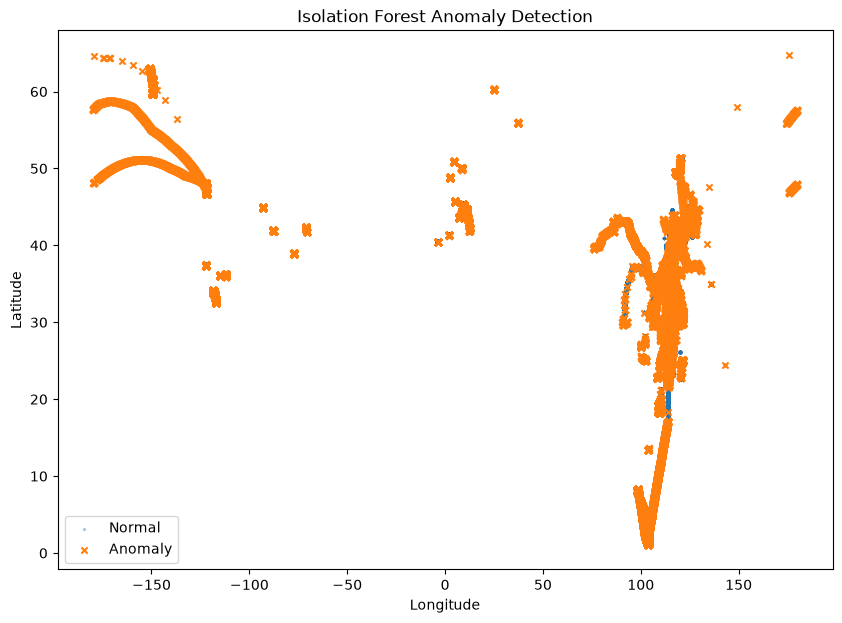

In [18]:
normal = df[
    df["anomaly"] == 1
]

anomalies = df[
    df["anomaly"] == -1
]

plt.figure(figsize=(10, 7))

plt.scatter(
    normal["longitude"],
    normal["latitude"],
    s=2,
    alpha=0.3,
    label="Normal"
)

plt.scatter(
    anomalies["longitude"],
    anomalies["latitude"],
    s=20,
    marker="x",
    label="Anomaly"
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Isolation Forest Anomaly Detection")

plt.legend()

plt.show()

In [19]:
anomalies_by_hour = (
    anomalies
    .groupby("hour")
    .size()
    .reset_index(
        name="anomaly_count"
    )
)

anomalies_by_hour

,hour,anomaly_count
0,0,13879
1,1,16385
2,2,23410
3,3,18042
4,4,17684
5,5,8129
6,6,5024
7,7,5538
8,8,7285
9,9,9395


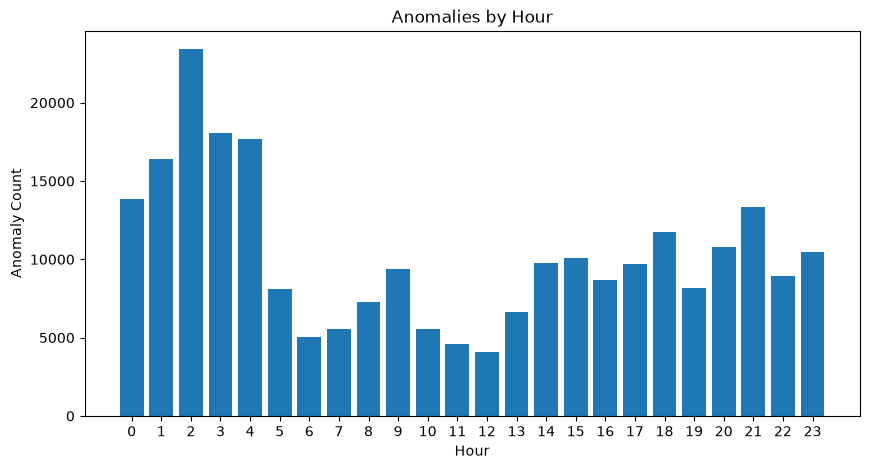

In [20]:
plt.figure(figsize=(10, 5))

plt.bar(
    anomalies_by_hour["hour"],
    anomalies_by_hour["anomaly_count"]
)

plt.xlabel("Hour")
plt.ylabel("Anomaly Count")
plt.title("Anomalies by Hour")
plt.xticks(range(24))

plt.show()

In [21]:
anomalies_by_cluster = (
    anomalies
    .groupby("cluster")
    .size()
    .reset_index(
        name="anomaly_count"
    )
    .sort_values(
        "anomaly_count",
        ascending=False
    )
)

anomalies_by_cluster

,cluster,anomaly_count
5,5,118826
4,4,30858
2,2,30110
0,0,18057
8,8,14414
6,6,11084
1,1,9222
9,9,8230
3,3,5559
7,7,932


In [22]:
df.to_csv(
    "../data/processed/gps_anomalies.csv",
    index=False
)

print(
    "Anomaly dataset saved successfully!"
)

Anomaly dataset saved successfully!


In [23]:
os.makedirs(
    "../models",
    exist_ok=True
)

In [24]:
joblib.dump(
    isolation_model,
    "../models/anomaly_model.pkl"
)

joblib.dump(
    scaler,
    "../models/anomaly_scaler.pkl"
)

print("Anomaly models saved successfully!")

Anomaly models saved successfully!


In [25]:
anomaly_summary = pd.DataFrame({
    "Metric": [
        "Total Points",
        "Normal Points",
        "Anomalous Points",
        "Anomaly Percentage"
    ],
    "Value": [
        total_points,
        normal_count,
        anomaly_count,
        round(anomaly_percentage, 2)
    ]
})

anomaly_summary

,Metric,Value
0,Total Points,24730077.0
1,Normal Points,24482785.0
2,Anomalous Points,247292.0
3,Anomaly Percentage,1.0


In [26]:
anomaly_summary.to_csv(
    "../data/processed/anomaly_summary.csv",
    index=False
)

In [27]:
print("========== ANOMALY DETECTION ==========")

print(
    "Total points:",
    total_points
)

print(
    "Normal points:",
    normal_count
)

print(
    "Anomalous points:",
    anomaly_count
)

print(
    "Anomaly percentage:",
    round(
        anomaly_percentage,
        2
    ),
    "%"
)

print("\nModels saved:")
print(
    os.listdir("../models")
)

========== ANOMALY DETECTION ==========
Total points: 24730077
Normal points: 24482785
Anomalous points: 247292
Anomaly percentage: 1.0 %

Models saved:
['anomaly_model.pkl', 'anomaly_scaler.pkl', 'clustering_scaler.pkl', 'clustering_model.pkl']
